In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 군집화

# 1. 데이터 생성
- 남자, 여자의 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
random.randint(40,95) # 40이상 95이하 정수 중 하나를 무작위 선택 반환

93

In [4]:
data = []
for i in range(50) :
    # 여자 데이터(몸무게, 키)
    data.append([random.randint(40,70), random.randint(140,170)])
    # 남자 데이터
    data.append([random.randint(60,95), random.randint(160,195)])
data

[[52, 154],
 [86, 164],
 [43, 147],
 [67, 161],
 [43, 163],
 [86, 190],
 [52, 145],
 [75, 192],
 [54, 161],
 [84, 187],
 [50, 164],
 [70, 177],
 [56, 166],
 [89, 189],
 [51, 142],
 [87, 173],
 [43, 143],
 [66, 182],
 [65, 147],
 [89, 161],
 [65, 145],
 [78, 188],
 [61, 147],
 [78, 183],
 [49, 162],
 [92, 184],
 [60, 142],
 [78, 172],
 [56, 153],
 [61, 182],
 [48, 153],
 [83, 189],
 [57, 143],
 [94, 165],
 [68, 156],
 [83, 185],
 [40, 148],
 [79, 189],
 [55, 160],
 [81, 178],
 [54, 158],
 [73, 184],
 [47, 165],
 [67, 160],
 [53, 157],
 [94, 186],
 [56, 143],
 [65, 167],
 [70, 160],
 [65, 177],
 [47, 166],
 [77, 180],
 [54, 148],
 [70, 173],
 [43, 150],
 [87, 191],
 [59, 163],
 [63, 171],
 [41, 159],
 [93, 192],
 [44, 168],
 [81, 171],
 [47, 159],
 [86, 174],
 [44, 169],
 [74, 173],
 [52, 168],
 [69, 191],
 [45, 161],
 [94, 183],
 [58, 165],
 [69, 187],
 [54, 160],
 [66, 166],
 [49, 150],
 [82, 162],
 [45, 156],
 [94, 164],
 [56, 140],
 [90, 180],
 [42, 163],
 [61, 181],
 [65, 143],
 [89

In [10]:
# 여자 데이터
for female in data[::2] :
    print(female, end=' ')
print('\n-----------------------------------------------------------------------------')
# 남자 데이터
for male in data[1::2] :
    print(male, end=' ')

[52, 154] [43, 147] [43, 163] [52, 145] [54, 161] [50, 164] [56, 166] [51, 142] [43, 143] [65, 147] [65, 145] [61, 147] [49, 162] [60, 142] [56, 153] [48, 153] [57, 143] [68, 156] [40, 148] [55, 160] [54, 158] [47, 165] [53, 157] [56, 143] [70, 160] [47, 166] [54, 148] [43, 150] [59, 163] [41, 159] [44, 168] [47, 159] [44, 169] [52, 168] [45, 161] [58, 165] [54, 160] [49, 150] [45, 156] [56, 140] [42, 163] [65, 143] [59, 142] [45, 167] [40, 153] [48, 160] [49, 151] [70, 147] [63, 157] [48, 145] 
-----------------------------------------------------------------------------
[86, 164] [67, 161] [86, 190] [75, 192] [84, 187] [70, 177] [89, 189] [87, 173] [66, 182] [89, 161] [78, 188] [78, 183] [92, 184] [78, 172] [61, 182] [83, 189] [94, 165] [83, 185] [79, 189] [81, 178] [73, 184] [67, 160] [94, 186] [65, 167] [65, 177] [77, 180] [70, 173] [87, 191] [63, 171] [93, 192] [81, 171] [86, 174] [74, 173] [69, 191] [94, 183] [69, 187] [66, 166] [82, 162] [94, 164] [90, 180] [61, 181] [89, 170] [

## 데이터 체크

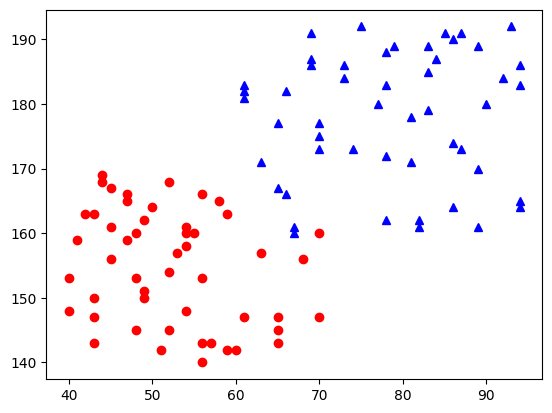

In [23]:
# print('여자 몸무게 :', [i[0] for i in data[::2]])
# print('\n ---------------------------------------')
# print('여자 키 :', [i[1] for i in data[::2]])
# print('\n ---------------------------------------')
# print('남자 몸무게 :', [i[0] for i in data[1::2]])
# print('\n ---------------------------------------')
# print('남자 키 :', [i[1] for i in data[1::2]])
# for d in data[::2] :
#     plt.plot(d[0],d[1],'o', color = 'r')
plt.plot([d[0] for d in data[::2]], [d[1] for d in data[::2]], 'o',color='r')
plt.plot([d[0] for d in data[1::2]], [d[1] for d in data[1::2]],'^', color='b')

# 2. 군집화 로직

In [24]:
# 초기 랜던 지점 2개
random_points = [[random.randint(40,95),random.randint(140,195)],
                [random.randint(40,95),random.randint(140,195)]]
random_points

[[60, 145], [92, 149]]

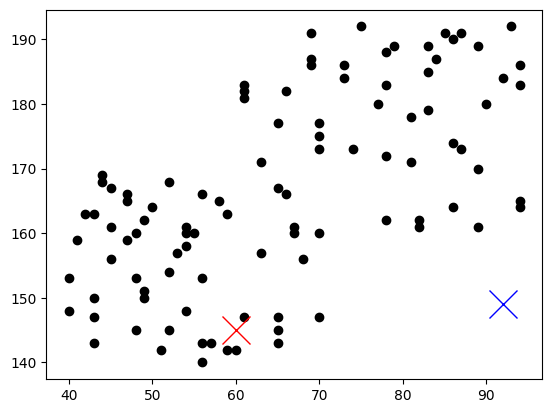

In [30]:
plt.plot([d[0] for d in data], [d[1] for d in data], 'o',color='k')
plt.plot(random_points[0][0], random_points[0][1], 'x', color = 'r', markersize=20) # 기준점 1
plt.plot(random_points[1][0], random_points[1][1], 'x', color = 'b', markersize=20) # 기준점 2

In [31]:
# 두 점의 거리를 return (0,0) ~ (4,3) 
def dist(a,b) :
    return np.sqrt(((a[0] - b[0])**2) + ((a[1] - b[1])**2))

In [34]:
a=[1,0] ; b=[4,3]
dist(a,b)

4.242640687119285

In [35]:
# 두 영역 random_points[0]과 random_points[1]을 기준으로 나눈 두 영역
group1 = [] # random_points[0]이 가까운 그룹
group2 = [] # random_points[1]이 가까운 그룹
for d in data :
    if dist(random_points[0],d) < dist(random_points[1],d) :
        group1.append(d) # random_points[0](기준점1)에 가까운 그룹
    else :
        group2.append(d) # random_points[1](기준점2)에 가까운 그룹
len(group1), len(group2)

(66, 34)

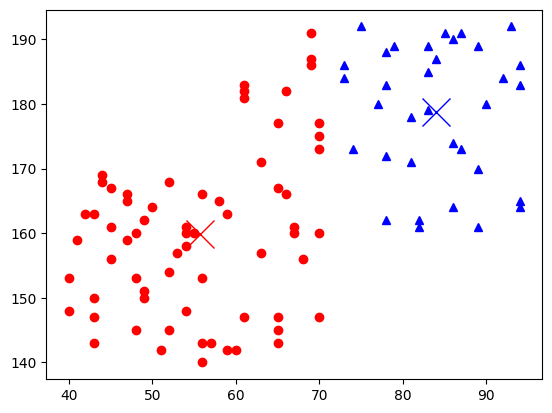

In [46]:
# 새로운 그룹 group1 과 group2, 초기 랜덤 지점
plt.plot([d[0] for d in group1],[d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],[d[1] for d in group2], '^', color='b')
plt.plot(random_points[0][0],random_points[0][1], 'x', color='r', markersize=20)
plt.plot(random_points[1][0],random_points[1][1], 'x', color='b', markersize=20)
plt.show()

In [44]:
# 기준점 이동 : group1의 중심점, group2의 중심점
X1 = sum([d[0] for d in group1])/len(group1)
Y1 = sum([d[1] for d in group1])/len(group1)
X2 = sum([d[0] for d in group2])/len(group2)
Y2 = sum([d[1] for d in group2])/len(group2)
random_points = [[X1,Y1],[X2,Y2]]

In [45]:
random_points # 기존 [[60, 145], [92, 149]] => 변화 후 [[55.67, 159.89],[84.03, 178.76]]

[[55.666666666666664, 159.8939393939394],
 [84.02941176470588, 178.76470588235293]]

# 3. 전체 코드(for문 이용)
- data 생성
- 랜덤포인트 2지점
- for문 시작
    - 랜덤포인트 2지점 기준으로 group화 => group1, group2
    - 랜덤포인트 이동(group1 중간점, group2 중간점)
- 데이터 점검

초기 point : [[95, 152], [54, 156]]
1번째 points : [[85.73333333333333, 175.2], [58.81428571428572, 160.0142857142857]]
2번째 points : [[83.34285714285714, 177.25714285714287], [58.03076923076923, 157.73846153846154]]
3번째 points : [[81.2439024390244, 176.34146341463415], [56.91525423728814, 156.38983050847457]]
4번째 points : [[80.70454545454545, 175.38636363636363], [56.035714285714285, 156.07142857142858]]
5번째 points : [[80.44444444444444, 175.17777777777778], [55.8, 155.8909090909091]]
6번째 points : [[80.44444444444444, 175.17777777777778], [55.8, 155.8909090909091]]
7번째 points : [[80.44444444444444, 175.17777777777778], [55.8, 155.8909090909091]]
8번째 points : [[80.44444444444444, 175.17777777777778], [55.8, 155.8909090909091]]
9번째 points : [[80.44444444444444, 175.17777777777778], [55.8, 155.8909090909091]]
10번째 points : [[80.44444444444444, 175.17777777777778], [55.8, 155.8909090909091]]


(140.0, 195.0)

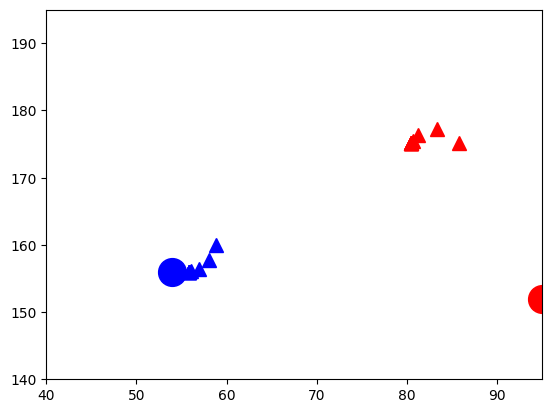

In [65]:
# 데이터 생성
data = []
for i in range(50) :
    # 여자 데이터(몸무게, 키)
    data.append([random.randint(40,70), random.randint(140,170)])
    # 남자 데이터
    data.append([random.randint(60,95), random.randint(160,195)])
# 랜던 포인트 2지점 지정
points = [[random.randint(40,95),random.randint(140,195)],
          [random.randint(40,95),random.randint(140,195)]]
print(f'초기 point : {points}')
plt.plot(points[0][0], points[0][1], 'o', color='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'o', color='b', markersize=20)
# for문 시작
    # 랜덤포인트 2지점 기준으로 group화 => group1, group2

for i in range(10) :
    group1 = [] # points[0]과 가까운그룹
    group2 = [] # points[1]과 가까운 그룹
    for d in data :
        if dist(d, points[0]) < dist(d, points[1]) :
            group1.append(d)
        else :
            group2.append(d)
            
    # 새로운 포인트 할당
    sumX = 0; sumY = 0
    for g in group1 :
        sumX += g[0]
        sumY += g[1]
    points[0] = [sumX / len(group1), sumY / len(group1)]
    sumX = 0; sumY = 0
    for g in group2 :
        sumX += g[0]
        sumY += g[1]
    points[1] = [sumX / len(group2), sumY / len(group2)]
    print(f'{i+1}번째 points : {points}')
    plt.plot(points[0][0], points[0][1], '^', color='r', markersize=10)
    plt.plot(points[1][0], points[1][1], '^', color='b', markersize=10)
plt.xlim([40,95])
plt.ylim([140,195])

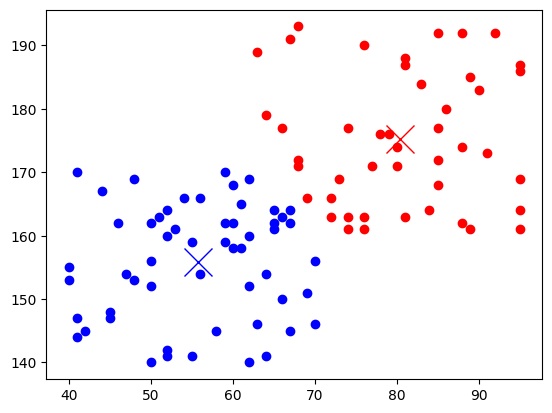

In [68]:
plt.plot([d[0] for d in group1],[d[1] for d in group1], 'o',color = 'r')
plt.plot([d[0] for d in group2],[d[1] for d in group2], 'o',color = 'b')
plt.plot(points[0][0],points[0][1],'x',color='r', markersize=20)
plt.plot(points[1][0],points[1][1],'x',color='b', markersize=20)

# 4. api(sklearn)를 이용한 군집화
- sklearn 머신러닝
    * 예측모델 
        ; 분류, 회귀, 군집 분석
        fit(학습), predict(예측)
    * 변환모델
        ; 전처리 ex. 스케일 조정
        fit(학습), transform(변환함수)

In [70]:
# 군집분석 라이브러리가 joblib 충돌 경고 메세지 출력. 아래와 같은 코드로 프로세스 병렬 진행(멀티쓰레드)을 막으면서 방지 가능
import os
os.environ['OMP_NUM_THREADS'] = "1"

In [76]:
data = np.array(data)
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 2개 그룹으로 나눠라
              init = 'random', # 초기 중심점 랜덤하게
              n_init = 10, # 10번 반복 실행
              random_state = 7)
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [82]:
# 중심점
model.cluster_centers_

array([[ 80.44444444, 175.17777778],
       [ 55.8       , 155.89090909]])

In [83]:
# 중심점
model.cluster_centers_

array([1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

In [90]:
groups1 = data[model.labels_ == 1]
groups2 = data[model.labels_ == 0]
c1, c2 = model.cluster_centers_

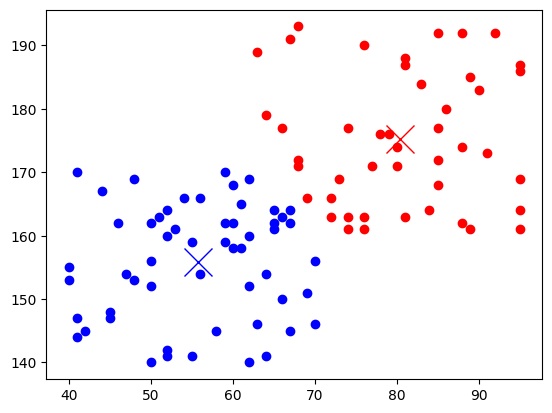

In [97]:
plt.plot([d[0] for d in group1],[d[1] for d in group1],'o',color = 'r')
plt.plot([d[0] for d in group2],[d[1] for d in group2],'o',color = 'b')
plt.plot(c1[0],c1[1], 'x', color='r', markersize=20)
plt.plot(c2[0],c2[1], 'x', color='b', markersize=20)